In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("cleaned_dataset.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
print("Rows:", df.shape[0])
print("column:", df.shape[1])
df.info()

Rows: 1200
column: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](

In [6]:
product_sales = (df.groupby("Product")["TotalPrice"].sum().sort_values(ascending = False).head(10))

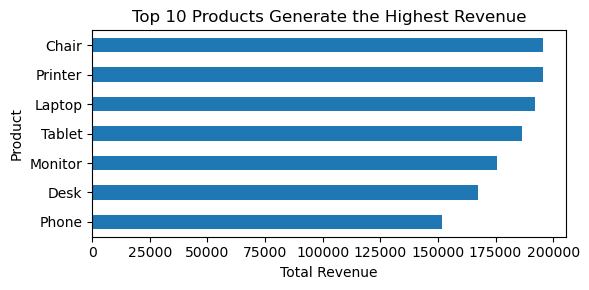

In [13]:
plt.figure(figsize=(6,3))
product_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products Generate the Highest Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [16]:
print("Top Revenue Product:",product_sales.idxmax())
print("Revenue:",round(product_sales.max(), 2))

Top Revenue Product: Chair
Revenue: 195620.11


In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
monthly_sales = (df.groupby(df["Date"].dt.to_period("M"))["TotalPrice"].sum())

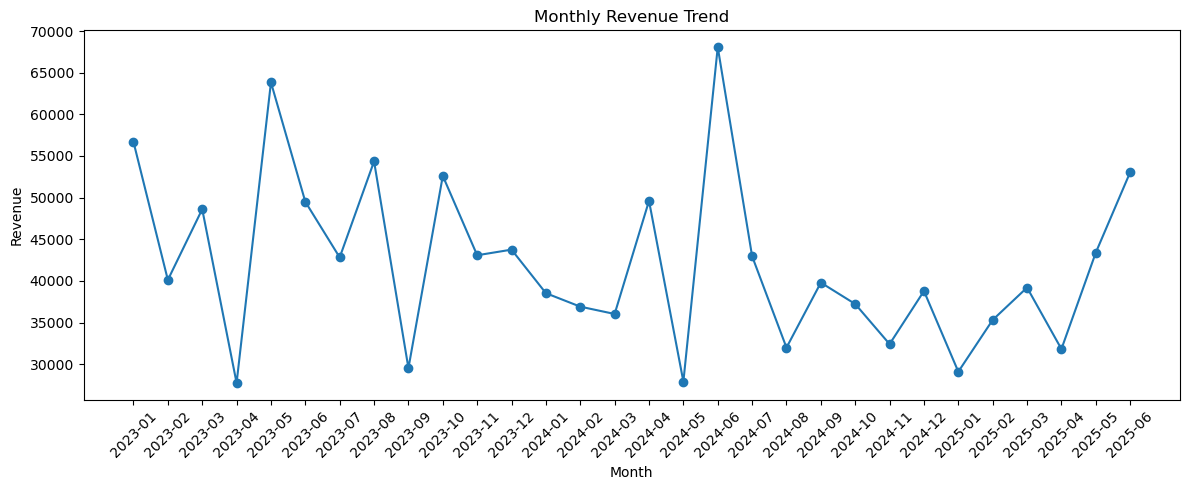

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
highest_month = monthly_sales.idxmax()
lowest_month = monthly_sales.idxmin()

print("Highest Revenue Month:", highest_month)
print("Highest Revenue:", round(monthly_sales.max(), 2))

print("Lowest Revenue Month:", lowest_month)
print("Lowest Revenue:", round(monthly_sales.min(), 2))

Highest Revenue Month: 2024-06
Highest Revenue: 68068.54
Lowest Revenue Month: 2023-04
Lowest Revenue: 27751.71


In [25]:
payment_sales = (df.groupby("PaymentMethod")["TotalPrice"].sum().sort_values(ascending=False))

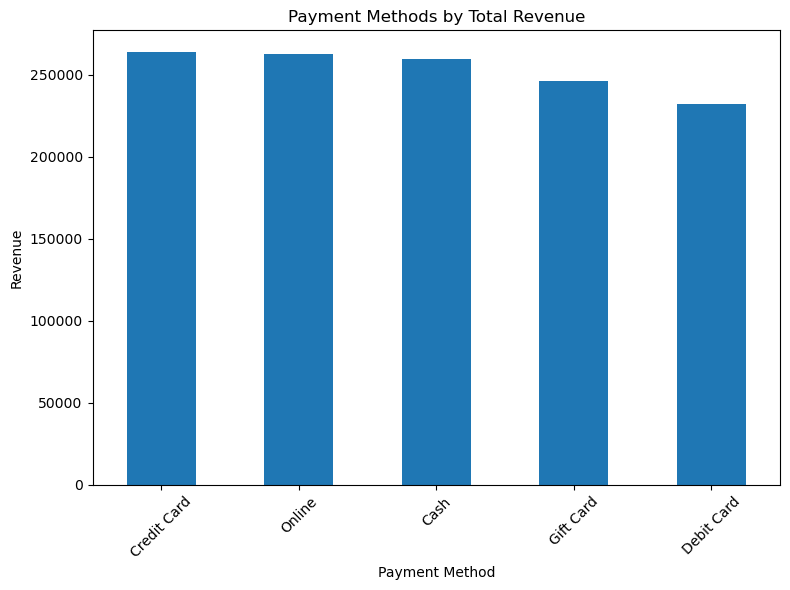

In [30]:
plt.figure(figsize=(8, 6))
payment_sales.plot(kind="bar")

plt.title("Payment Methods by Total Revenue")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
status_count = df["OrderStatus"].value_counts()

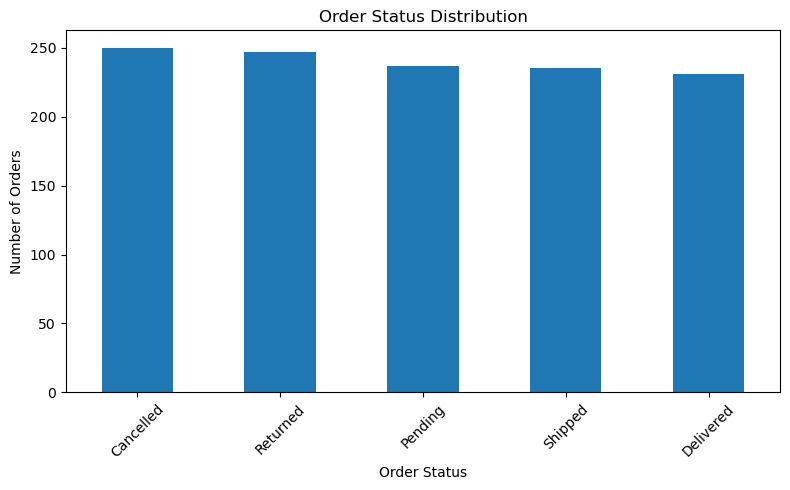

In [32]:
plt.figure(figsize=(8, 5))

status_count.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

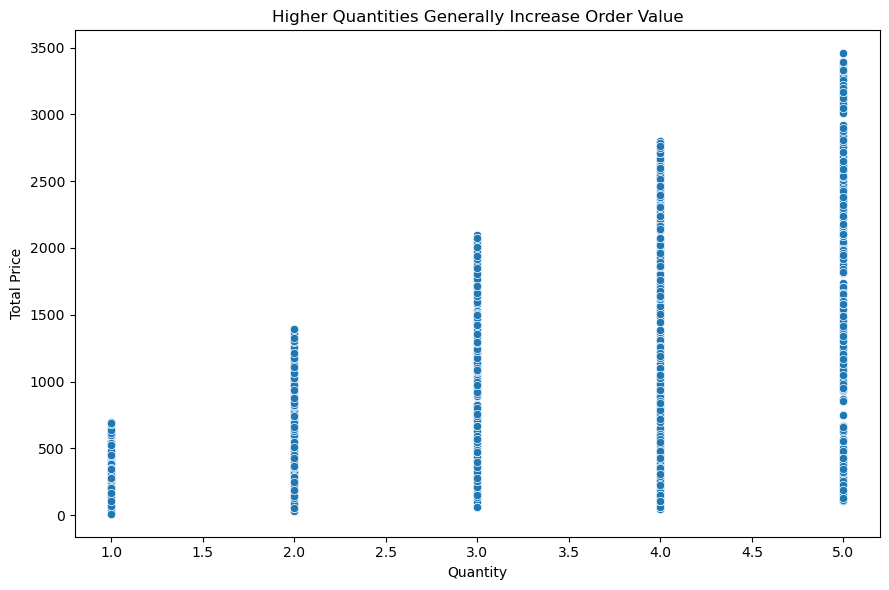

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice")

plt.title("Higher Quantities Generally Increase Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.tight_layout()
plt.show()

In [34]:
product_quantity = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [35]:
total_orders = len(df)
total_revenue = df["TotalPrice"].sum()
average_order = df["TotalPrice"].mean()
median_order = df["TotalPrice"].median()

In [36]:
top_product = product_sales.idxmax()
top_payment = payment_sales.idxmax()
top_status = status_count.idxmax()
best_month = monthly_sales.idxmax()